In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pathlib import Path

# Verificar versin de TensorFlow
print(" TensorFlow versin:", tf.__version__)


 TensorFlow versin: 2.20.0


In [2]:
BASE_DIR = Path("../data/processed/classification_split")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Entrenando con rutas:")
print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)


Entrenando con rutas:
Train: ..\data\processed\classification_split\train
Val: ..\data\processed\classification_split\val
Test: ..\data\processed\classification_split\test


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 1928 images belonging to 2 classes.
Found 422 images belonging to 2 classes.
Found 419 images belonging to 2 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Verificar versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")

# Crear el modelo base
try:
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    print("✅ MobileNetV2 creado exitosamente")
except Exception as e:
    print(f"❌ Error al crear MobileNetV2: {e}")
    print("Intentando con pesos aleatorios...")
    base_model = MobileNetV2(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3)
    )

# Congelar el modelo base
base_model.trainable = False

# Ver resumen
print("\nResumen del modelo base:")
print(f"Número de capas: {len(base_model.layers)}")
print(f"Número de parámetros totales: {base_model.count_params():,}")

TensorFlow version: 2.20.0
✅ MobileNetV2 creado exitosamente

Resumen del modelo base:
Número de capas: 154
Número de parámetros totales: 2,257,984


In [5]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Construcción del modelo final
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
#Callbacks (early stopping + guardar mejor modelo)
# Exportacin: mejor modelo en ../models/classification/modelo_clasificador.h5
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("../models/classification/modelo_clasificador.h5",
                    save_best_only=True,
                    monitor="val_loss")
]


In [7]:
#Entrenamiento
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7382 - auc: 0.7915 - loss: 0.5278 - precision: 0.7626 - recall: 0.7988

61/61 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8397 - auc: 0.9145 - loss: 0.3776 - precision: 0.8452 - recall: 0.8840 - val_accuracy: 0.9882 - val_auc: 0.9978 - val_loss: 0.1320 - val_precision: 1.0000 - val_recall: 0.9790
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9634 - auc: 0.9946 - loss: 0.1476 - precision: 0.9714 - recall: 0.9664

61/61 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9704 - auc: 0.9964 - loss: 0.1293 - precision: 0.9714 - recall: 0.9775 - val_accuracy: 0.9929 - val_auc: 0.9978 - val_loss: 0.0780 - val_precision: 1.0000 - val_recall: 0.9874
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9870 - auc: 0.9981 - loss: 0.0898 - precision: 0.9873 - recall: 0.9907

61/61 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9876 - auc: 0.9987 - loss: 0.0810 - precision: 0.9848 - recall: 0.9937 - val_accuracy: 0.9882 - val_auc: 0.9976 - val_loss: 0.0663 - val_precision: 1.0000 - val_recall: 0.9790
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9883 - auc: 0.9977 - loss: 0.0698 - precision: 0.9872 - recall: 0.9922

61/61 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9886 - auc: 0.9987 - loss: 0.0639 - precision: 0.9901 - recall: 0.9901 - val_accuracy: 0.9882 - val_auc: 0.9980 - val_loss: 0.0562 - val_precision: 1.0000 - val_recall: 0.9790
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9943 - auc: 0.9998 - loss: 0.0501 - precision: 0.9926 - recall: 0.9975

61/61 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9938 - auc: 0.9998 - loss: 0.0466 - precision: 0.9937 - recall: 0.9955 - val_accuracy: 0.9905 - val_auc: 0.9981 - val_loss: 0.0473 - val_precision: 1.0000 - val_recall: 0.9832
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9927 - auc: 0.9992 - loss: 0.0418 - precision: 0.9937 - recall: 0.9937 - val_accuracy: 0.9834 - val_auc: 0.9970 - val_loss: 0.0532 - val_precision: 1.0000 - val_recall: 0.9706
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9933 - auc: 0.9997 - loss: 0.0334 - precision: 0.9937 - recall: 0.9946 - val_accuracy: 0.9834 - val_auc: 0.9971 - val_loss: 0.0515 - val_precision: 1.0000 - val_recall: 0.9706
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9971 - auc: 0.9999 - loss: 0.0268 - precision: 0.9974 - recall: 0.9976

61/61 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9964 - auc: 0.9997 - loss: 0.0290 - precision: 0.9982 - recall: 0.9955 - val_accuracy: 0.9834 - val_auc: 0.9972 - val_loss: 0.0464 - val_precision: 1.0000 - val_recall: 0.9706
Epoch 9/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9959 - auc: 0.9999 - loss: 0.0266 - precision: 0.9964 - recall: 0.9964 - val_accuracy: 0.9834 - val_auc: 0.9974 - val_loss: 0.0532 - val_precision: 1.0000 - val_recall: 0.9706
Epoch 10/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9958 - auc: 0.9999 - loss: 0.0238 - precision: 0.9988 - recall: 0.9937

61/61 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9948 - auc: 0.9999 - loss: 0.0243 - precision: 0.9964 - recall: 0.9946 - val_accuracy: 0.9858 - val_auc: 0.9972 - val_loss: 0.0434 - val_precision: 1.0000 - val_recall: 0.9748
Epoch 11/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9984 - auc: 1.0000 - loss: 0.0190 - precision: 0.9991 - recall: 0.9982 - val_accuracy: 0.9858 - val_auc: 0.9972 - val_loss: 0.0461 - val_precision: 1.0000 - val_recall: 0.9748
Epoch 12/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9964 - auc: 1.0000 - loss: 0.0202 - precision: 0.9973 - recall: 0.9964 - val_accuracy: 0.9858 - val_auc: 0.9972 - val_loss: 0.0459 - val_precision: 1.0000 - val_recall: 0.9748
Epoch 13/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9964 - auc: 1.0000 - loss: 0.0169 - precision: 0.9973 - recall: 0.9964 - val_accuracy: 0.9858 - val_auc: 0.9972 - val_loss: 0.0435 - val_precision: 1.0000 - val_recall: 0.9748
Epoch 14/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 107s 

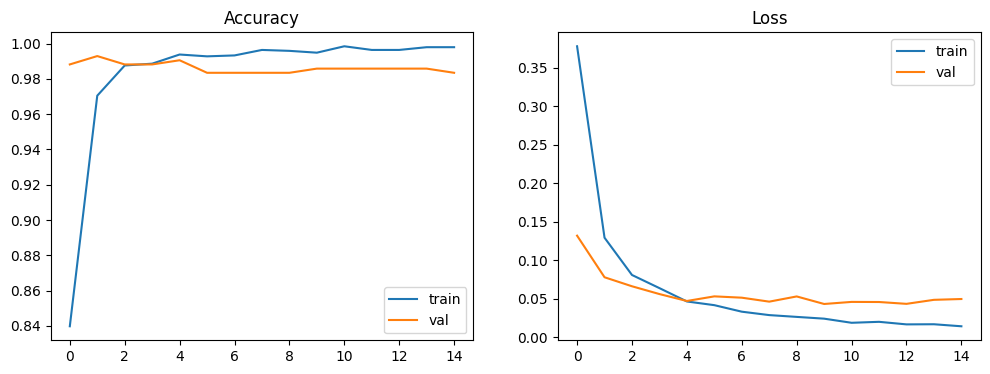

In [8]:
#Gráficos de accuracy y loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")

plt.show()


In [9]:
#Evaluaci?n en test
results = model.evaluate(test_gen, return_dict=True)
print("Test Accuracy:", results.get("accuracy"))
print("Test Metrics:", results)


14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9952 - auc: 1.0000 - loss: 0.0299 - precision: 0.9917 - recall: 1.0000
Test Accuracy: 0.9952267408370972
Test Metrics: {'accuracy': 0.9952267408370972, 'auc': 0.9999535083770752, 'loss': 0.029948918148875237, 'precision': 0.9917012453079224, 'recall': 1.0}


In [10]:
# Metricas adicionales en test
test_gen.reset()
probs = model.predict(test_gen, verbose=0).reshape(-1)
y_true = test_gen.classes
y_pred = (probs > 0.5).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
auc = roc_auc_score(y_true, probs)
cm = confusion_matrix(y_true, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)


Precision: 0.991701244813278
Recall: 1.0
F1: 0.9958333333333333
AUC: 0.999953509995351
Confusion Matrix:
 [[178   2]
 [  0 239]]


In [11]:
# Exportacin: modelo TFLite en ../models/classification/modelo_clasificador.tflite
#Guardar modelo TFLite (para usar offline)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("../models/classification/modelo_clasificador.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo TFLite exportado")


INFO:tensorflow:Assets written to: C:\Users\Leo\AppData\Local\Temp\tmpv2ox4dgd\assets


INFO:tensorflow:Assets written to: C:\Users\Leo\AppData\Local\Temp\tmpv2ox4dgd\assets


Saved artifact at 'C:\Users\Leo\AppData\Local\Temp\tmpv2ox4dgd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2582634646224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634646992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634648912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634648528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634647376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634649104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634647568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634649680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634649296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634647184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2582634